# Preparando los datos

El conjunto de datos que utilizaremos en este tutorial es `make_circles` de `scikit-learn` (consulta la documentación). Se trata de un conjunto de datos de ejemplo que contiene un círculo grande y otro más pequeño en un plano bidimensional, además de dos características. Para nuestra demostración, utilizamos 10 000 muestras y añadimos ruido gaussiano con una desviación estándar de 0,05 a los datos.

Antes de construir nuestra red neuronal, es recomendable dividir los datos en conjuntos de entrenamiento y prueba para poder evaluar el rendimiento del modelo con datos no vistos.

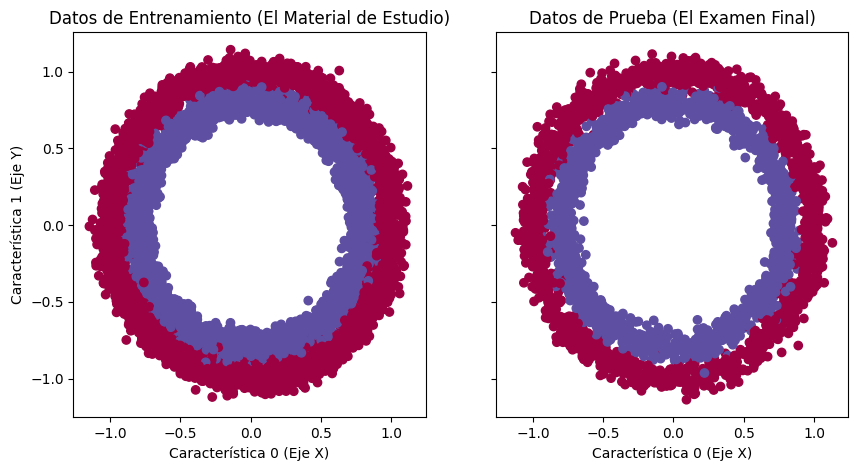

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 1. CREACIÓN DEL DATASET (Nuestro "Problema de Juguete")
# Generamos 10,000 puntos distribuidos en dos círculos concéntricos.
# X: Las coordenadas (x, y) de cada punto (Nuestras "Características" o "Features").
# y: La etiqueta real del punto (0 si es el círculo exterior, 1 si es el interior).
X, y = make_circles(n_samples=10000,
                    noise=0.05,        # Agregamos 5% de ruido para que no sea un círculo perfecto (más realista)
                    random_state=26)   # Semilla: Asegura que a todos los alumnos les salgan los mismos datos

# 2. DIVISIÓN DE DATOS (Entrenamiento vs. Prueba)
# ¡Paso vital! Separamos los datos para que la red no "haga trampa" memorizando las respuestas.
# test_size=0.33 significa que el 67% es para estudiar (entrenar) y el 33% es para el examen final (probar).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=26)

# 3. VISUALIZACIÓN DE LOS DATOS
# Creamos una figura con dos sub-gráficos (1 fila, 2 columnas)
fig, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10, 5))

# Gráfico 1: Datos de Entrenamiento
# c=y_train le dice a matplotlib que pinte los puntos de distinto color según su etiqueta.
train_ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Spectral)
train_ax.set_title("Datos de Entrenamiento (El Material de Estudio)")
train_ax.set_xlabel("Característica 0 (Eje X)")
train_ax.set_ylabel("Característica 1 (Eje Y)")

# Gráfico 2: Datos de Prueba
test_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Spectral) # Añadido el cmap para que combinen
test_ax.set_title("Datos de Prueba (El Examen Final)")
test_ax.set_xlabel("Característica 0 (Eje X)")

# Mostramos la ventana con los gráficos
plt.show()

# De Numpy a tensores

El siguiente paso es convertir los datos de entrenamiento y prueba de matrices NumPy a tensores PyTorch. Para ello, crearemos un conjunto de datos personalizado para nuestros archivos de entrenamiento y prueba. También utilizaremos el módulo Dataloader de PyTorch para entrenar nuestros datos por lotes. Aquí está el código:

In [5]:
import warnings
warnings.filterwarnings("ignore")

# ¡OJO! Esta linea (!pip install...) es para Google Colab o Jupyter.
!pip install torch -q

import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

# 1. EL MOLDE DE LOS DATOS (Clase Dataset)
# PyTorch necesita saber cómo leer nuestro dataset específico y cuántos datos hay.
class Data(Dataset):
    def __init__(self, X, y):
        # Convertimos las matrices de NumPy a Tensores de PyTorch.
        # astype(np.float32) es VITAL: PyTorch usa 32 bits por defecto para redes neuronales.
        # Si usamos 64 bits (Float64), el entrenamiento será el doble de lento sin mejora real.
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.float32))
        self.len = self.X.shape[0]

    def __getitem__(self, index):
        # Este método permite pedir un dato específico, ej: mi_dataset[5]
        return self.X[index], self.y[index]

    def __len__(self):
        # Devuelve el tamaño total del dataset
        return self.len

# 2. EL TAMAÑO DEL LOTE (Batch Size)
# Cuántos ejemplos le mostramos a la red antes de que actualice sus pesos.
batch_size = 64

# 3. EL ADMINISTRADOR DE LOGÍSTICA (DataLoader)
# Instanciamos nuestra clase Dataset con los datos de entrenamiento
train_data = Data(X_train, y_train)
# El DataLoader se encarga de agrupar los datos de a 64 y de desordenarlos (shuffle)
train_dataloader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

# Hacemos lo mismo para los datos de prueba
test_data = Data(X_test, y_test)
test_dataloader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

# 4. CONTROL DE CALIDAD (Revisamos que la tubería funcione)
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Lote (Batch) número: {batch+1}")
    print(f"Forma de X (Entradas): {X.shape}") # Debería ser [64, 2] -> 64 puntos, 2 coordenadas (x,y)
    print(f"Forma de y (Etiquetas): {y.shape}") # Debería ser [64] -> 64 respuestas correctas
    break # Rompemos el ciclo porque solo queremos ver el primer lote de prueba

Lote (Batch) número: 1
Forma de X (Entradas): torch.Size([64, 2])
Forma de y (Etiquetas): torch.Size([64])


#Implementación de redes neuronales y entrenamiento del modelo

Vamos a implementar una red neuronal simple de dos capas que utiliza la función de activación ReLU (torch.nn.functional.relu). Para ello, crearemos una clase llamada NeuralNetwork que hereda de nn.Module, la clase base para todos los módulos de redes neuronales de PyTorch.

Aquí está el código:

In [6]:
import torch
from torch import nn
from torch import optim

# 1. ARQUITECTURA DE LA RED
input_dim = 2   # 2 Entradas: Las coordenadas X e Y de nuestros puntos (make_circles)
hidden_dim = 10 # 10 Neuronas Ocultas: Proporcionan la "capacidad de procesamiento"
output_dim = 1  # 1 Salida: Probabilidad (de 0 a 1) de que el punto sea del círculo interior

# 2. DEFINICIÓN DEL MODELO (Heredando de nn.Module)
# nn.Module es el "chasis". Al heredar de él, PyTorch activa Autograd
# automáticamente para todos los pesos que pongamos dentro.
class NeuralNetwork(nn.Module):

    # __init__: El "Almacén de Componentes"
    # Aquí definimos las piezas de hardware que usaremos, pero aún no las conectamos.
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralNetwork, self).__init__() # Inicializamos la clase padre

        # Capa 1: Conecta las 2 entradas con las 10 neuronas ocultas.
        # nn.Linear crea automáticamente la matriz de Pesos (W) y Sesgos (b).
        self.layer_1 = nn.Linear(input_dim, hidden_dim)

        # Inicialización de Kaiming (He Initialization)
        # Buena práctica de ingeniería: No dejamos los pesos al azar. Esta función
        # inicializa los pesos con una varianza específica para que la señal
        # no se "apague" al pasar por la función ReLU.
        nn.init.kaiming_uniform_(self.layer_1.weight, nonlinearity="relu")

        # Capa 2: Conecta las 10 neuronas ocultas con la única salida.
        self.layer_2 = nn.Linear(hidden_dim, output_dim)

    # forward: El "Diagrama de Cableado"
    # Aquí le decimos a PyTorch CÓMO fluye la señal desde la entrada (x) hasta la salida.
    def forward(self, x):
        # Paso 1: La entrada pasa por la Capa 1 y luego por un ReLU (Rectificador).
        # ReLU actúa como un diodo: si la señal es negativa, la hace 0. Si es positiva, la deja pasar.
        # Esto introduce la "No-Linealidad" necesaria para resolver los círculos.
        x = torch.nn.functional.relu(self.layer_1(x))

        # Paso 2: La señal pasa por la Capa 2 y luego por una función Sigmoide.
        # La Sigmoide "aplasta" cualquier valor numérico a un rango entre 0 y 1.
        x = torch.nn.functional.sigmoid(self.layer_2(x))

        return x # Entregamos la probabilidad final

# 3. INSTANCIACIÓN DEL MODELO
model = NeuralNetwork(input_dim, hidden_dim, output_dim)
print(model)

NeuralNetwork(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=1, bias=True)
)


#Entrenamiento del Modelo
Para entrenar el modelo, debemos definir una función de pérdida para calcular los gradientes y un optimizador para actualizar los parámetros. Para nuestra demostración, utilizaremos entropía cruzada binaria y descenso de gradiente estocástico con una tasa de aprendizaje de 0,1.

In [7]:
import torch

# 1. HIPERPARÁMETROS (Las "Perillas" de Control)
learning_rate = 0.1 # Tasa de Aprendizaje: Qué tan grandes son los pasos que damos al bajar la montaña.
num_epochs = 100    # Épocas: Cuántas veces el modelo estudiará el dataset COMPLETO.

# 2. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR
# BCELoss (Binary Cross Entropy Loss): Es la fórmula matemática ideal para evaluar
# errores cuando la respuesta final solo puede ser 0 o 1 (Círculo exterior o interior).
loss_fn = nn.BCELoss()

# SGD (Stochastic Gradient Descent): Nuestro algoritmo de optimización.
# Toma los parámetros del modelo y la tasa de aprendizaje para actualizar los pesos.
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Lista para guardar el error a lo largo del tiempo y poder graficarlo después
loss_values = []

# 3. EL BUCLE DE ENTRENAMIENTO (Training Loop)
for epoch in range(num_epochs):
    # Recorremos el dataset en lotes de 64 (nuestro DataLoader)
    for X_batch, y_batch in train_dataloader:

        # PASO 1: Limpiar la pizarra
        # ¿Recuerdan que Autograd ACUMULA gradientes? Aquí los borramos (los hacemos 0)
        # para que el cálculo del lote actual no se contamine con el del lote anterior.
        optimizer.zero_grad()

        # PASO 2: Predicción (Forward Pass)
        # El modelo intenta adivinar las respuestas con sus pesos actuales.
        # pred tendrá forma [64, 1] (64 predicciones, 1 columna)
        pred = model(X_batch)

        # PASO 3: Calcular el Error (Loss)
        # y_batch original tiene forma [64] (un arreglo plano).
        # .unsqueeze(-1) lo transforma a [64, 1] para que las dimensiones encajen
        # perfectamente con "pred" y podamos restarlos/compararlos matemáticamente.
        loss = loss_fn(pred, y_batch.unsqueeze(-1))
        loss_values.append(loss.item()) # Guardamos el valor numérico del error

        # PASO 4: Backpropagation (Autograd en acción)
        # PyTorch viaja hacia atrás y calcula las derivadas de cada peso (las pendientes).
        loss.backward()

        # PASO 5: Actualizar los Pesos
        # El optimizador da el paso hacia "abajo de la montaña" usando los gradientes calculados.
        optimizer.step()

print(f"Entrenamiento Completo tras {num_epochs} épocas.")

Entrenamiento Completo tras 100 épocas.


#Visualización de la Función de Perdida
Dado que hemos registrado los valores de pérdida, podemos visualizar la pérdida del modelo a lo largo del tiempo.

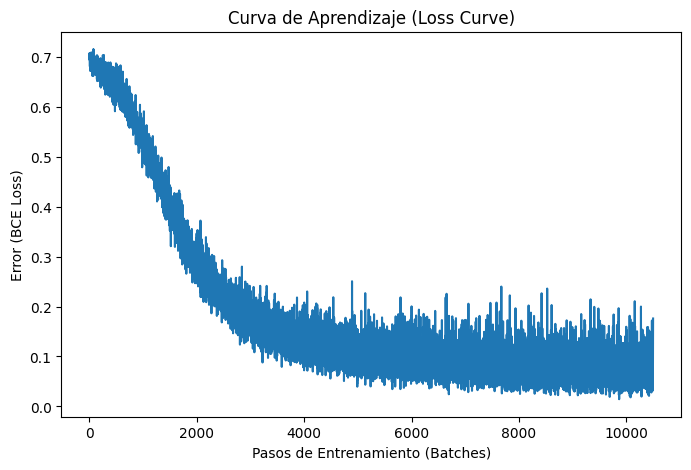

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. PREPARANDO EL EJE X
# Como guardamos el error por cada Lote (Batch), la longitud de la lista
# es igual al total de "pasos" que dio el optimizador.
step = range(len(loss_values))

# 2. CREANDO EL GRÁFICO
fig, ax = plt.subplots(figsize=(8, 5))

# Graficamos: Eje X (Pasos) vs Eje Y (Error numérico)
# Convertimos loss_values a un arreglo de NumPy por eficiencia
plt.plot(step, np.array(loss_values))

# 3. ETIQUETAS (El estándar de reporte)
plt.title("Curva de Aprendizaje (Loss Curve)")

# ¡Corrección de Ingeniero! No son épocas, son actualizaciones de pesos (Steps).
plt.xlabel("Pasos de Entrenamiento (Batches)")
plt.ylabel("Error (BCE Loss)")

# Mostramos el resultado
plt.show()

# Predicción del Modelo
La visualización anterior muestra la pérdida de nuestro modelo a lo largo de 100 épocas. Inicialmente, la pérdida comienza en 0,7 y disminuye gradualmente, lo que indica que nuestro modelo ha mejorado sus predicciones con el tiempo. Sin embargo, el modelo parece estancarse alrededor de la época 60, lo que puede deberse a diversos factores, como que se encuentre en la región de un mínimo local o global de la función de pérdida.

No obstante, el modelo ha sido entrenado y está listo para realizar predicciones en nuevas instancias. En la siguiente sección, veremos cómo hacerlo.

In [9]:
import itertools  # Importamos esto al inicio del script para aplanar listas

# 1. INICIALIZACIÓN DE MÉTRICAS
y_pred = []   # Aquí guardaremos lo que la red "cree" que es la respuesta
y_test = []   # Aquí guardaremos la respuesta real (la pauta del examen)
correct = 0   # Contador de aciertos
total = 0     # Contador total de preguntas

# 2. MODO EVALUACIÓN (¡Apagando Autograd!)
# Como solo estamos tomando una prueba, NO queremos que el modelo aprenda de estos datos.
# torch.no_grad() apaga el motor de Autograd. Esto hace que el código sea mucho más rápido
# y consuma menos memoria RAM, ya que no construye el grafo de derivadas.
with torch.no_grad():
    # Recorremos el DataLoader de PRUEBA (el 33% de los datos que el modelo nunca ha visto)
    for X, y in test_dataloader:

        # PASO A: El modelo rinde el examen (Forward pass)
        outputs = model(X)

        # PASO B: Decisión (Umbral / Threshold)
        # La salida es una probabilidad (ej. 0.8). Usamos NumPy para decir:
        # "Si es menor a 0.5, es el círculo 0. Si es mayor o igual, es el círculo 1."
        predicted = np.where(outputs.numpy() < 0.5, 0, 1)

        # PASO C: Limpieza de datos
        # Convertimos la matriz de predicciones en una lista plana y simple
        predicted = list(itertools.chain(*predicted))

        # Guardamos las predicciones y las etiquetas reales para un análisis posterior
        y_pred.append(predicted)
        y_test.append(y.numpy())

        # PASO D: Calificación
        total += y.size(0)  # Sumamos la cantidad de datos en este lote (ej. 64)

        # Comparamos la predicción con la realidad. Sumamos 1 por cada coincidencia.
        correct += (predicted == y.numpy()).sum().item()

# 3. RESULTADO FINAL
# Calculamos el porcentaje de aciertos: (Buenas / Totales) * 100
print(f'Precisión (Accuracy) de la red en los 3300 datos de prueba: {100 * correct // total}%')

Precisión (Accuracy) de la red en los 3300 datos de prueba: 97%


# Matriz de Confusión
Profundizamos aún más utilizando la matriz de confusión y el informe de clasificación de scikit-learn para comprender mejor el rendimiento de nuestro modelo.

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1635
         1.0       0.98      0.98      0.98      1665

    accuracy                           0.98      3300
   macro avg       0.98      0.98      0.98      3300
weighted avg       0.98      0.98      0.98      3300



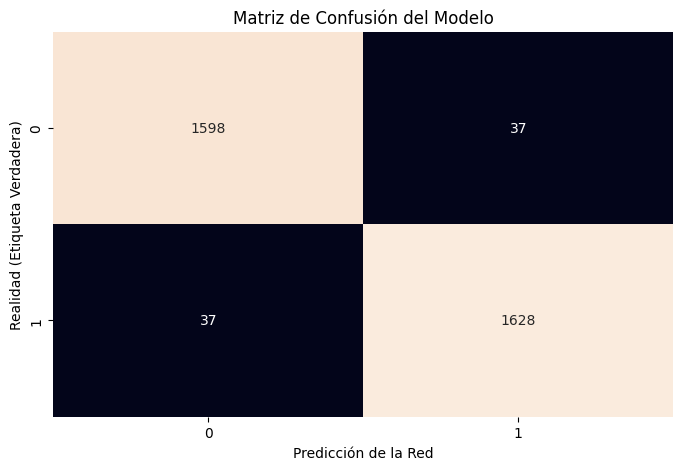

In [10]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

# 1. UNIFICANDO LOS DATOS (Flattening)
# En el bucle anterior, guardamos los datos lote por lote (batch).
# y_pred es actualmente una "lista de listas". Para que scikit-learn lo entienda,
# necesitamos "aplanarlo" a una sola lista continua de 3,300 predicciones.
y_pred = list(itertools.chain(*y_pred))
y_test = list(itertools.chain(*y_test))

# 2. EL REPORTE DE CALIFICACIONES (Classification Report)
# Desglosa el rendimiento de la red mucho más allá del simple "Accuracy".
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# 3. LA MATRIZ DE CONFUSIÓN
# Es una tabla 2x2 que nos muestra exactamente en qué se equivocó el modelo.
# Nos dice cuántos 0s adivinó como 0s, cuántos 0s confundió con 1s, etc.
cf_matrix = confusion_matrix(y_test, y_pred)

# 4. VISUALIZACIÓN TÉRMICA (Heatmap)
# Configuramos el tamaño del lienzo
plt.subplots(figsize=(8, 5))

# sns.heatmap dibuja la matriz con colores.
# annot=True escribe los números dentro de los cuadros.
# cbar=False quita la barra de colores lateral (para un diseño más limpio).
# fmt="g" evita que los números se escriban en notación científica.
sns.heatmap(cf_matrix, annot=True, cbar=False, fmt="g")

plt.title("Matriz de Confusión del Modelo")
plt.xlabel("Predicción de la Red")
plt.ylabel("Realidad (Etiqueta Verdadera)")
plt.show()